In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import precision_recall_curve, roc_curve, auc, average_precision_score

from config.paths import (
    X_TEST, Y_TEST,
    LOGISTIC_REGRESSION_METRICS, LOGISTIC_REGRESSION_MODEL,
    RANDOM_FOREST_METRICS, RANDOM_FOREST_MODEL,
    XGBOOST_METRICS, XGBOOST_MODEL,
    RESULTS
)

X_test = pd.read_csv(X_TEST)
y_test = pd.read_csv(Y_TEST).squeeze()

# XGBoost needs the same bracket-free column names used during training
import re
X_test_xgb = X_test.copy()
X_test_xgb.columns = [re.sub(r'[\[\]<]', '', c).strip() for c in X_test_xgb.columns]

models = {
    'Logistic Regression': joblib.load(LOGISTIC_REGRESSION_MODEL),
    'Random Forest': joblib.load(RANDOM_FOREST_MODEL),
    'XGBoost': joblib.load(XGBOOST_MODEL),
}

metrics_files = {
    'Logistic Regression': LOGISTIC_REGRESSION_METRICS,
    'Random Forest': RANDOM_FOREST_METRICS,
    'XGBoost': XGBOOST_METRICS,
}

In [4]:
comparison_rows = []
for name, path in metrics_files.items():
    df = pd.read_csv(path, index_col=0)
    row = df['test'].copy()
    row.name = name
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df[['precision', 'recall', 'f1', 'roc_auc', 'average_precision']]
print(comparison_df)

                     precision    recall        f1   roc_auc  \
Logistic Regression   0.143959  0.823529  0.245077  0.906886   
Random Forest         0.750000  0.705882  0.727273  0.970052   
XGBoost               0.675000  0.794118  0.729730  0.962527   

                     average_precision  
Logistic Regression           0.396385  
Random Forest                 0.781378  
XGBoost                       0.811873  


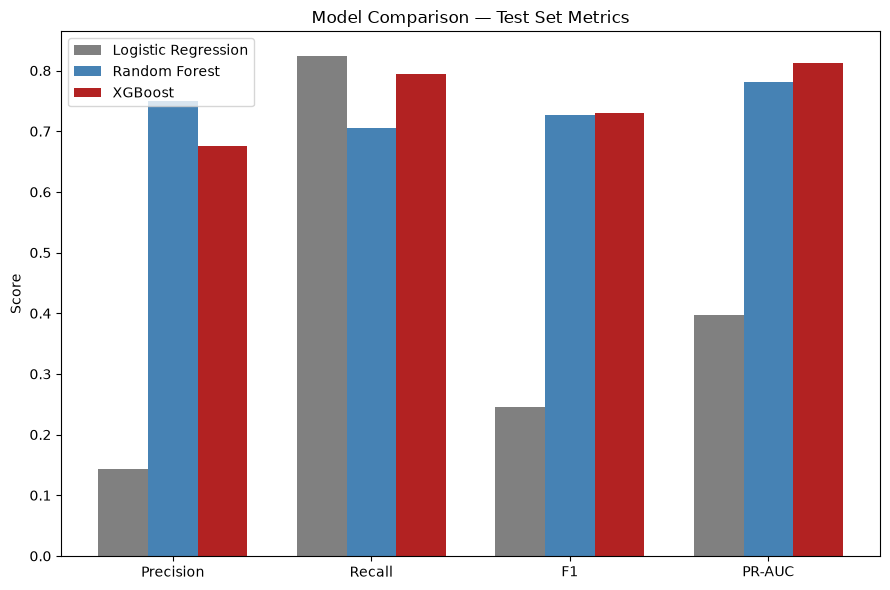

In [5]:
colors = {'Logistic Regression': 'gray', 'Random Forest': 'steelblue', 'XGBoost': 'firebrick'}

metrics_to_plot = ['precision', 'recall', 'f1', 'average_precision']
x = np.arange(len(metrics_to_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 6))
for i, (name, row) in enumerate(comparison_df.iterrows()):
    values = [row[m] for m in metrics_to_plot]
    ax.bar(x + i * width, values, width, label=name, color=colors[name])

ax.set_xticks(x + width)
ax.set_xticklabels(['Precision', 'Recall', 'F1', 'PR-AUC'])
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Test Set Metrics')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / "model_comparison_bars.png", dpi=300, bbox_inches="tight")
plt.show()